# Caso Literary Digest: Aprendizado de Máquina com a eleição de 1936

## Introdução e Preparações iniciais

**Cientistas de Dados:**
> Gustavo Pereira 11241104195
>
> João do Prado 11242100678
>
> Maria Nagahashi 11241105055
>
> Victor Fernandes 11241504620

---

### Caso Literary Digest: Salvando a Previsão da Eleição de 1936

*Em 1936, a revista The Literary Digest enviou cerca de 10 milhões de cartões postais e recebeu quase 2,4 milhões de respostas, prevendo uma vitória folgada do republicano Alf Landon sobre Franklin D. Roosevelt. O resultado real foi o oposto: Roosevelt venceu com 62% dos votos populares, e o episódio se tornou um dos maiores desastres preditivos da história da estatística, contribuindo para a falência da revista pouco tempo depois. Neste projeto, assumimos o papel de cientistas de dados forenses: usamos Pandas, NumPy e Scikit-Learn para limpar as bases históricas das eleições de 1932 e 1936, quantificar o viés de amostragem e de não-resposta que levou ao erro e construir um modelo simples de correção, capaz de aproximar a previsão de 1936 do resultado real a partir do comportamento eleitoral observado em 1932.*



### Dependências: Bibliotecas e Módulos necessários
---
* **Numpy:** usado nos cálculos numéricos e estatísticos do projeto (proporções, médias, desvio-padrão, etc.).
* **Pandas:** usado para carregar, limpar, transformar e consolidar os dados em `DataFrames`.
* **Sklearn:** será usado na etapa de modelagem preditiva, para construir o modelo de regressão que corrige a previsão de 1936 com base no comportamento eleitoral de 1932.
* **Matplotlib:** usado para exploração visual dos dados, através de gráficos.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Imports do sklearn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## 1. Conjunto de Dados: Importação, limpeza e estruturação

Os dados utilizados vêm do arquivo `LitDigestFull.xlsx`, que reúne três conjuntos:

* **Intenções de voto de 1936** apuradas pela pesquisa do Literary Digest (aba `"1936"`, colunas `A:AG`): quantas pessoas de cada lista de contato (Landon, Roosevelt ou Lemke) indicaram voto em cada candidato, e como essas mesmas pessoas haviam votado em 1932.
* **Resultado real da eleição de 1936** (aba `"1936"`, colunas `AI:BC`): votos e percentuais obtidos por cada candidato em cada estado, extraídos da Wikipedia.
* **Resultado real da eleição de 1932** (aba `"1932"`): usado como âncora do comportamento eleitoral passado, necessário para a etapa de modelagem preditiva.


In [5]:
DATASET_PATH = "LitDigestFull.xlsx"

*Conjunto intenções de voto de 1936*

In [6]:
df_pesquisa_intencoes = pd.read_excel(DATASET_PATH, sheet_name="1936",header=1, usecols="A:AG")
df_pesquisa_intencoes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   State                 50 non-null     object 
 1   Electoral Vote        50 non-null     int64  
 2   Landon                50 non-null     int64  
 3   Rep.                  50 non-null     int64  
 4   Dem.                  50 non-null     int64  
 5   Soc.                  50 non-null     int64  
 6   Others                50 non-null     int64  
 7   Did Not Vote          50 non-null     int64  
 8   Vote Not Indicated    50 non-null     int64  
 9   Unnamed: 9            0 non-null      float64
 10  Roosevelt (D)         50 non-null     int64  
 11  Rep..1                50 non-null     int64  
 12  Dem..1                50 non-null     int64  
 13  Soc..1                50 non-null     int64  
 14  Others.1              50 non-null     int64  
 15  Did Note Vote         50 

In [7]:
df_pesquisa_intencoes = df_pesquisa_intencoes.drop([col for col in df_pesquisa_intencoes.columns if col.startswith("Unnamed")], axis=1)
# Remove linhas vazias e desnecessárias
df_pesquisa_intencoes = df_pesquisa_intencoes.drop([48,49])

# Remove colunas com candidatos menores
# A coluna "Totals" ainda mantém o soma desses votos, então os números não serão perdidos
df_pesquisa_intencoes = df_pesquisa_intencoes.drop(["Thomas","Browder","Colvin","Aiken","Others.3"], axis=1)

In [8]:
df_pesquisa_intencoes.columns = [
    "State",
    "Electoral_vote",

    "L_indications",
    "L_rep",
    "L_dem",
    "L_soc",
    "L_others",
    "L_did_not_vote",
    "L_vote_not_indicated",

    "R_indications",
    "R_rep",
    "R_dem",
    "R_soc",
    "R_others",
    "R_did_not_vote",
    "R_vote_not_indicated",

    "K_indications",
    "K_rep",
    "K_dem",
    "K_soc",
    "K_others",
    "K_did_not_vote",
    "K_vote_not_indicated",

    "Others_indications",
    "Total_indications",
]
# Infos do DataFrame Pós-Limpeza de colunas vazias e da remoção dos candidatos menores.
df_pesquisa_intencoes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   State                 48 non-null     object
 1   Electoral_vote        48 non-null     int64 
 2   L_indications         48 non-null     int64 
 3   L_rep                 48 non-null     int64 
 4   L_dem                 48 non-null     int64 
 5   L_soc                 48 non-null     int64 
 6   L_others              48 non-null     int64 
 7   L_did_not_vote        48 non-null     int64 
 8   L_vote_not_indicated  48 non-null     int64 
 9   R_indications         48 non-null     int64 
 10  R_rep                 48 non-null     int64 
 11  R_dem                 48 non-null     int64 
 12  R_soc                 48 non-null     int64 
 13  R_others              48 non-null     int64 
 14  R_did_not_vote        48 non-null     int64 
 15  R_vote_not_indicated  48 non-null     int6

*Validação dos dados*

In [9]:
# Verificando inconsistência de respostas totais
_soma_candidatos = df_pesquisa_intencoes[["L_indications","R_indications","K_indications","Others_indications"]].sum(axis=1)
_inconsistencia_soma_total = (_soma_candidatos != df_pesquisa_intencoes["Total_indications"]).sum()

print(f"inconsistencia de respostas totais: {_inconsistencia_soma_total}")

# Verificando inconsistência de respostas em candidato específico
_soma_Landon = df_pesquisa_intencoes[["L_dem","L_soc","L_rep","L_did_not_vote","L_vote_not_indicated"]].sum(axis=1)
_inconsistencia_soma_Landon = (_soma_Landon != df_pesquisa_intencoes["L_indications"]).sum()

print(f"inconsistencia de respostas 'Landon': {_inconsistencia_soma_total}")

inconsistencia de respostas totais: 0
inconsistencia de respostas 'Landon': 0


*Conjunto dos votos de 1936*

In [10]:
df_votos = pd.read_excel(DATASET_PATH, sheet_name="1936", usecols="AI:BC")
df_votos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   State - 1936       49 non-null     object 
 1   Electoral votes    49 non-null     float64
 2   Roosevelt          49 non-null     float64
 3   %                  49 non-null     float64
 4   Electoral votes.1  49 non-null     object 
 5   Landon             49 non-null     float64
 6   %.1                49 non-null     float64
 7   Electoral votes.2  49 non-null     object 
 8   Lemke (Union).1    49 non-null     object 
 9   %.2                49 non-null     object 
 10  Electoral votes.3  49 non-null     object 
 11  Thomas (Soc.)      49 non-null     object 
 12  %.3                49 non-null     object 
 13  Electoral votes.4  49 non-null     object 
 14  Other              49 non-null     object 
 15  %.4                49 non-null     object 
 16  Electoral votes.5  49 non-nu

In [11]:
 # Criando "df_1936_votes_tratado"
 # Remove colunas desnecessárias
df_votos = df_votos.drop(["State"]+[col for col in df_votos.columns if (col.startswith("%") | col.startswith("Electoral votes."))], axis=1)\
.drop(
  # remove linhas vazias
  [48,49,50]
 # elimina espaços em branco dos nomes das colunas
).rename(columns = lambda x: x.strip())
df_votos.columns = [
    "State", "Electoral_votes", "Roosevelt_votes", "Landon_votes",
    "Lemke_votes", "Thomas_votes", "Other_votes", "Margin_votes",
    "Total_votes"
]

# Elimina "-", os trocando por 0
df_votos = df_votos.mask(df_votos == "-",0)

df_votos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   State            48 non-null     object 
 1   Electoral_votes  48 non-null     float64
 2   Roosevelt_votes  48 non-null     float64
 3   Landon_votes     48 non-null     float64
 4   Lemke_votes      48 non-null     object 
 5   Thomas_votes     48 non-null     object 
 6   Other_votes      48 non-null     object 
 7   Margin_votes     48 non-null     float64
 8   Total_votes      48 non-null     float64
dtypes: float64(5), object(4)
memory usage: 3.5+ KB


In [12]:
# Adiciona tabela para identificar vencedor de cada estado
df_votos["Electoral_winner_id"] = 0

# Define o identificador dos demais competidores
_landon_victories = ["Maine","Vermont"]
df_votos["Electoral_winner_id"] = df_votos["Electoral_winner_id"].mask(df_votos["State"].isin(_landon_victories),1)


*Conjunto dos votos de 1932*

In [13]:
df_votos_1932 = pd.read_excel(DATASET_PATH, sheet_name="1932", usecols="AB:AR")
df_votos_1932.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   State - 1932       49 non-null     object 
 1   Electoral votes    49 non-null     float64
 2   Roosevelt          49 non-null     float64
 3   %                  49 non-null     float64
 4   Electoral votes.1  49 non-null     object 
 5   Hoover             49 non-null     float64
 6   %.1                49 non-null     float64
 7   Electoral votes.2  49 non-null     object 
 8   Thomas (Soc.)      49 non-null     float64
 9   %.2                49 non-null     float64
 10  Electoral votes.3  49 non-null     object 
 11  Other              49 non-null     float64
 12  %.3                49 non-null     float64
 13  Electoral votes.4  48 non-null     object 
 14  Margin             49 non-null     object 
 15  %.4                49 non-null     object 
 16  Total votes        49 non-nu

In [14]:
# Remove valores duplicados ou desnecessários
df_votos_1932 = df_votos_1932.drop([col for col in df_votos_1932.columns if (col.startswith("%") | col.startswith("Electoral votes."))], axis=1)
# Remove linhas vazias
df_votos_1932 = df_votos_1932.drop([49,50,51])
# Renomeia colunas
df_votos_1932.columns = [
    "State", "Electoral_votes", "Roosevelt_votes_1932", "Hoover_votes_1932","Thomas_votes_1932",
    "Other_votes_1932", "Margin_1932", "Total_votes_1932"
]
df_votos_1932.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   State                 49 non-null     object 
 1   Electoral_votes       49 non-null     float64
 2   Roosevelt_votes_1932  49 non-null     float64
 3   Hoover_votes_1932     49 non-null     float64
 4   Thomas_votes_1932     49 non-null     float64
 5   Other_votes_1932      49 non-null     float64
 6   Margin_1932           49 non-null     object 
 7   Total_votes_1932      49 non-null     float64
dtypes: float64(6), object(2)
memory usage: 3.2+ KB


*Validação dos dados*

In [15]:
# verificando inconsistências nos votos totais
_soma_votos_1932 = df_votos_1932[["Roosevelt_votes_1932","Hoover_votes_1932","Thomas_votes_1932","Other_votes_1932"]].sum(axis=1)
_inconsistencia_votos_totais_1932 = (_soma_votos_1932 != df_votos_1932["Total_votes_1932"]).sum()

print(f"Número de inconsistências nos votos totais de 1932: {_inconsistencia_votos_totais_1932}")

Número de inconsistências nos votos totais de 1932: 0


*Criação do Dataframe principal*

In [16]:
df = df_pesquisa_intencoes\
.merge(df_votos.drop(["Electoral_votes"], axis=1), on="State", validate="one_to_one")\
.merge(df_votos_1932.drop(["Electoral_votes"], axis=1), on="State", validate="one_to_one")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   State                 48 non-null     object 
 1   Electoral_vote        48 non-null     int64  
 2   L_indications         48 non-null     int64  
 3   L_rep                 48 non-null     int64  
 4   L_dem                 48 non-null     int64  
 5   L_soc                 48 non-null     int64  
 6   L_others              48 non-null     int64  
 7   L_did_not_vote        48 non-null     int64  
 8   L_vote_not_indicated  48 non-null     int64  
 9   R_indications         48 non-null     int64  
 10  R_rep                 48 non-null     int64  
 11  R_dem                 48 non-null     int64  
 12  R_soc                 48 non-null     int64  
 13  R_others              48 non-null     int64  
 14  R_did_not_vote        48 non-null     int64  
 15  R_vote_not_indicated  48 

## 2. EDA: Análise exploratória e estastística descritiva

Antes de investigar o viés, esta seção faz a análise exploratória do `df` consolidado: visão geral da estrutura dos dados, cálculo das proporções de voto por estado (segundo a pesquisa do Digest e segundo o resultado real da eleição) e a medição da discrepância estadual entre previsão e realidade.

*Visão geral do Dataframe consolidado*

In [17]:
print(f'Dimensão do DataFrame consolidado: {df.shape}')

print("\nInformações estruturais:")
df.info()

print("\nResumo estatístico das colunas numéricas:")
display(df.describe())
# print(f'Dimensão do DataFrame {df_pesquisa_intencoes}\n')
# print(f'\nDimensão do DataFrame {df_votos}')

Dimensão do DataFrame consolidado: (48, 39)

Informações estruturais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   State                 48 non-null     object 
 1   Electoral_vote        48 non-null     int64  
 2   L_indications         48 non-null     int64  
 3   L_rep                 48 non-null     int64  
 4   L_dem                 48 non-null     int64  
 5   L_soc                 48 non-null     int64  
 6   L_others              48 non-null     int64  
 7   L_did_not_vote        48 non-null     int64  
 8   L_vote_not_indicated  48 non-null     int64  
 9   R_indications         48 non-null     int64  
 10  R_rep                 48 non-null     int64  
 11  R_dem                 48 non-null     int64  
 12  R_soc                 48 non-null     int64  
 13  R_others              48 non-null     int64  
 14  R_did_

,Electoral_vote,L_indications,L_rep,L_dem,L_soc,L_others,L_did_not_vote,L_vote_not_indicated,R_indications,R_rep,...,Roosevelt_votes,Landon_votes,Margin_votes,Total_votes,Electoral_winner_id,Roosevelt_votes_1932,Hoover_votes_1932,Thomas_votes_1932,Other_votes_1932,Total_votes_1932
count,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,...,4.800000e+01,4.800000e+01,4.800000e+01,4.800000e+01,48.000000,4.800000e+01,4.800000e+01,48.000000,48.000000,4.800000e+01
mean,11.062500,26802.312500,19072.125000,5180.062500,116.541667,17.083333,1272.083333,1144.416667,20132.333333,2958.708333,...,5.781852e+05,3.475576e+05,2.306414e+05,9.510014e+05,0.041667,4.754433e+05,3.283595e+05,18435.104167,5926.708333,8.281645e+05
std,8.997414,36244.883885,26414.031766,6766.744647,171.403215,23.098156,1659.925605,1511.699563,26080.955195,4325.342682,...,6.821083e+05,4.675547e+05,2.459290e+05,1.173696e+06,0.201941,5.091258e+05,4.309618e+05,31703.083767,9594.513315,9.657900e+05
min,3.000000,848.000000,216.000000,272.000000,0.000000,0.000000,36.000000,37.000000,955.000000,88.000000,...,3.192500e+04,1.646000e+03,-4.249000e+04,4.384800e+04,0.000000,2.875600e+04,1.978000e+03,0.000000,0.000000,4.143000e+04
25%,4.000000,4037.250000,2758.250000,1042.250000,15.000000,2.000000,251.750000,167.000000,5115.250000,493.250000,...,1.555500e+05,6.431575e+04,8.096650e+04,2.274125e+05,0.000000,1.373528e+05,7.085525e+04,1546.500000,264.750000,2.195412e+05
50%,9.000000,11744.500000,8279.000000,2471.500000,34.000000,7.500000,696.500000,541.500000,12342.500000,1283.500000,...,3.115520e+05,1.576715e+05,1.555260e+05,4.826110e+05,0.000000,2.551750e+05,1.513250e+05,4268.500000,2151.000000,4.239760e+05
75%,12.250000,32352.250000,22852.000000,6560.250000,134.250000,23.000000,1334.000000,1437.500000,20745.000000,3317.250000,...,7.077295e+05,3.850528e+05,2.713425e+05,1.133164e+06,0.000000,6.274570e+05,3.716482e+05,20470.250000,4840.000000,1.011304e+06
max,47.000000,162260.000000,114574.000000,33052.000000,805.000000,115.000000,7125.000000,6659.000000,139277.000000,18241.000000,...,3.293222e+06,2.180670e+06,1.112552e+06,5.596398e+06,1.000000,2.534959e+06,1.937963e+06,177397.000000,38295.000000,4.688614e+06


*Proporções de voto por estado: previsão da pesquisa*

In [18]:
# Proporção (%) de indicações de cada candidato dentro do total de respostas de cada estado
# L = indicaram Landon / R = indicaram Roosevelt
# K = indicaram Lemke / Others = demais candidatos
poll_map = {
    "Poll_pct_Landon": "L_indications",
    "Poll_pct_Roosevelt": "R_indications",
    "Poll_pct_Lemke": "K_indications",
    "Poll_pct_Others": "Others_indications",
}

for col_destino, col_origem in poll_map.items():
    df[col_destino] = df[col_origem] / df["Total_indications"] * 100

df[["State", *poll_map.keys()]].head()

,State,Poll_pct_Landon,Poll_pct_Roosevelt,Poll_pct_Lemke,Poll_pct_Others
0,Alabama,23.054321,75.958713,0.512318,0.474648
1,Arizona,52.211796,44.124218,2.323503,1.340483
2,Arkansas,25.844402,72.182163,1.309298,0.664137
3,California,51.465203,44.410268,2.861414,1.263116
4,Colorado,59.542298,37.426267,2.161577,0.869857


*Proporções de voto por estado: resultado real da eleição*

In [19]:
# Garante que as colunas de votos reais estejam em formato numérico
colunas_votos_reais = ["Landon_votes", "Roosevelt_votes", "Lemke_votes", "Thomas_votes", "Other_votes", "Total_votes"]
df[colunas_votos_reais] = df[colunas_votos_reais].apply(pd.to_numeric, errors="coerce")

real_map = {
    "Real_pct_Landon": "Landon_votes",
    "Real_pct_Roosevelt": "Roosevelt_votes",
    "Real_pct_Lemke": "Lemke_votes",
}

for col_destino, col_origem in real_map.items():
    df[col_destino] = df[col_origem] / df["Total_votes"] * 100

df[["State", *real_map.keys()]].head()

,State,Real_pct_Landon,Real_pct_Roosevelt,Real_pct_Lemke
0,Alabama,12.846057,86.518144,0.200186
1,Arizona,26.926701,69.845284,2.663434
2,Arkansas,17.856685,81.798320,0.002229
3,California,31.696415,66.953960,0.000000
4,Colorado,37.092886,60.370505,2.038536


### *Discrepância estadual: pesquisa (Digest) x resultado real*
*O erro é calculado, por estado, como a diferença entre o percentual de Landon previsto pela pesquisa e o percentual de Landon realmente obtido. Valores positivos indicam estados em que o Digest superestimou Landon (o que ocorreu em quase todos os casos); valores próximos de zero indicam estados em que a pesquisa acertou o percentual real.*

In [20]:
df["Erro_Landon_pp"] = df["Poll_pct_Landon"] - df["Real_pct_Landon"]
df["Erro_Landon_abs"] = df["Erro_Landon_pp"].abs()

erro = df["Erro_Landon_pp"].to_numpy()

print("Estatísticas descritivas do erro entre pesquisa e resultado real (em pontos percentuais):")
print(f"Média:         {np.mean(erro):.2f} p.p.")
print(f"Mediana:       {np.median(erro):.2f} p.p.")
print(f"Desvio-padrão: {np.std(erro):.2f} p.p.")
print(f"Mínimo:        {np.min(erro):.2f} p.p.")
print(f"Máximo:        {np.max(erro):.2f} p.p.")

Estatísticas descritivas do erro entre pesquisa e resultado real (em pontos percentuais):
Média:         17.40 p.p.
Mediana:       17.35 p.p.
Desvio-padrão: 7.01 p.p.
Mínimo:        0.46 p.p.
Máximo:        31.21 p.p.


*Estados com maior e menor discrepância entre a previsão e o resultado real:*

In [21]:
print("Top 5 estados com MAIOR discrepância (pesquisa mais distante da realidade):")
display(
    df.sort_values("Erro_Landon_abs", ascending=False)
      [["State", "Poll_pct_Landon", "Real_pct_Landon", "Erro_Landon_pp"]]
      .head()
)

print("\n\nTop 5 estados com MENOR discrepância (pesquisa mais próxima da realidade):")
display(
    df.sort_values("Erro_Landon_abs", ascending=True)
      [["State", "Poll_pct_Landon", "Real_pct_Landon", "Erro_Landon_pp"]]
      .head()
)

Top 5 estados com MAIOR discrepância (pesquisa mais distante da realidade):


,State,Poll_pct_Landon,Real_pct_Landon,Erro_Landon_pp
18,Massachusetts,72.978161,41.764342,31.213818
36,Rhode Island,70.191659,40.179897,30.011762
46,Wisconsin,57.109061,30.259026,26.850035
44,Washington,56.523924,29.883092,26.640832
26,New Hampshire,74.238026,47.975829,26.262197




Top 5 estados com MENOR discrepância (pesquisa mais próxima da realidade):


,State,Poll_pct_Landon,Real_pct_Landon,Erro_Landon_pp
30,North Carolina,27.057053,26.598282,0.458771
39,Tennessee,32.967510,30.746761,2.220748
14,Kentucky,43.307087,39.915872,3.391215
2,Arkansas,25.844402,17.856685,7.987717
43,Virginia,37.490832,29.390000,8.100832


*Visualização das 15 maiores discrepâncias estaduais:*

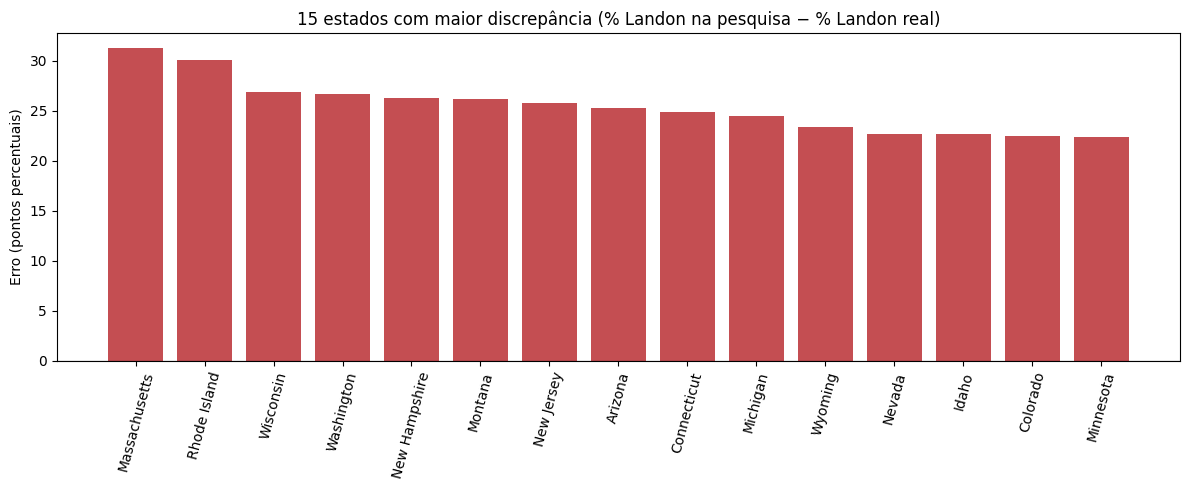

In [22]:
top15_erro = df.sort_values("Erro_Landon_abs", ascending=False).head(15)

plt.figure(figsize=(12, 5))
plt.bar(top15_erro["State"], top15_erro["Erro_Landon_pp"], color="#C44E52")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("15 estados com maior discrepância (% Landon na pesquisa − % Landon real)")
plt.ylabel("Erro (pontos percentuais)")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

*Dispersão entre o percentual previsto e o percentual real de Landon em cada estado. Quanto mais distante os pontos estiverem da diagonal (previsão perfeita), maior o erro da pesquisa naquele estado - e é visível que praticamente todos os estados ficam acima da diagonal, ou seja, a pesquisa superestimou Landon de forma sistemática, e não apenas por acaso:*

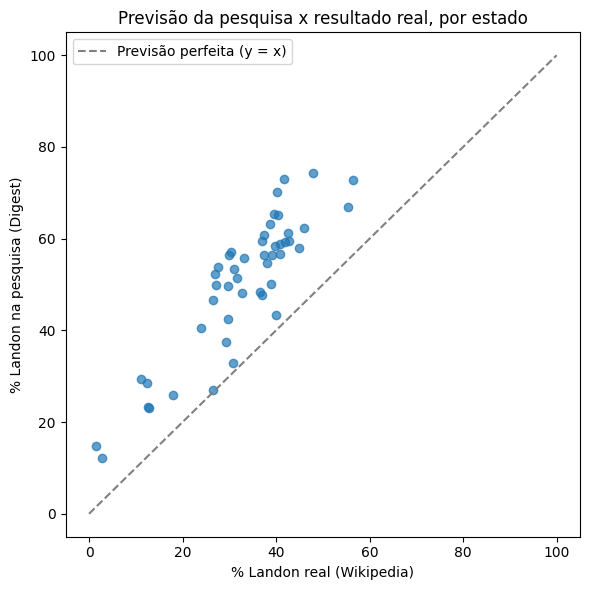

In [23]:
plt.figure(figsize=(6, 6))
plt.scatter(df["Real_pct_Landon"], df["Poll_pct_Landon"], alpha=0.7)

lims = [0, 100]
plt.plot(lims, lims, linestyle="--", color="gray", label="Previsão perfeita (y = x)")

plt.xlabel("% Landon real (Wikipedia)")
plt.ylabel("% Landon na pesquisa (Digest)")
plt.title("Previsão da pesquisa x resultado real, por estado")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Diagnóstico de Viés: Identificação e análise de enviesamento dos dados

Nesta seção, o objetivo é investigar as causas do erro medido na Parte 2: o viés de amostragem (quem foi selecionado para responder à pesquisa, a partir da composição partidária de cada lista de contato) e o viés de não-resposta (quem efetivamente respondeu, a partir das taxas de resposta por lista e por estado).

*Composição partidária por lista de contato (L, R, K):*

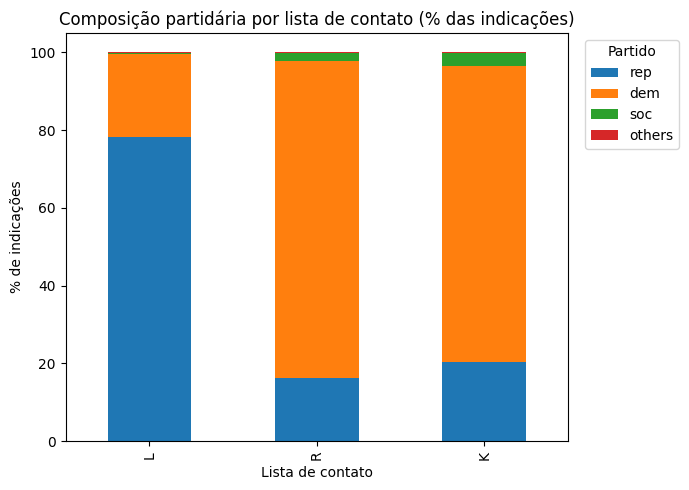

,rep,dem,soc,others
L,78.209922,21.242116,0.477908,0.070054
R,16.314082,81.499189,2.104824,0.081905
K,20.274644,76.237897,3.181687,0.305772


In [24]:
grupos = ["L", "R", "K"]
partidos = ["rep", "dem", "soc", "others"]

# Soma nacional de indicações de cada partido, por lista
composicao = pd.DataFrame({
    grupo: [df[f"{grupo}_{partido}"].sum() for partido in partidos]
    for grupo in grupos
}, index=partidos)

# Converte para proporção dentro de cada lista (apenas entre quem indicou um partido)
composicao_pct = composicao / composicao.sum(axis=0) * 100

composicao_pct.T.plot(kind="bar", stacked=True, figsize=(7, 5))
plt.title("Composição partidária por lista de contato (% das indicações)")
plt.ylabel("% de indicações")
plt.xlabel("Lista de contato")
plt.legend(title="Partido", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

composicao_pct.T

*Taxa de resposta por lista:*

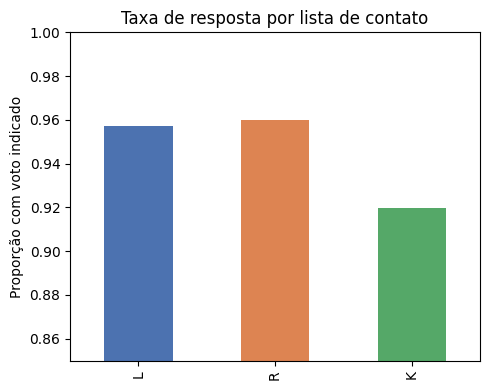

,Taxa de resposta
L,0.957302
R,0.959902
K,0.919558


In [25]:
# Taxa de resposta por lista = 1 - (sem indicação de voto / total de contatados na lista)
# ("did_not_vote" é considerado resposta válida: a pessoa respondeu que não votaria)
taxa_resposta = {}
for grupo in grupos:
    contatados = df[f"{grupo}_indications"].sum()
    sem_indicacao = df[f"{grupo}_vote_not_indicated"].sum()
    taxa_resposta[grupo] = 1 - (sem_indicacao / contatados)

taxa_resposta = pd.Series(taxa_resposta, name="Taxa de resposta")

taxa_resposta.plot(kind="bar", figsize=(5, 4), color=["#4C72B0", "#DD8452", "#55A868"])
plt.title("Taxa de resposta por lista de contato")
plt.ylabel("Proporção com voto indicado")
plt.ylim(0.85, 1)
plt.tight_layout()
plt.show()

taxa_resposta

*Taxa de não-resposta por estado (agregando as três listas de contato):*

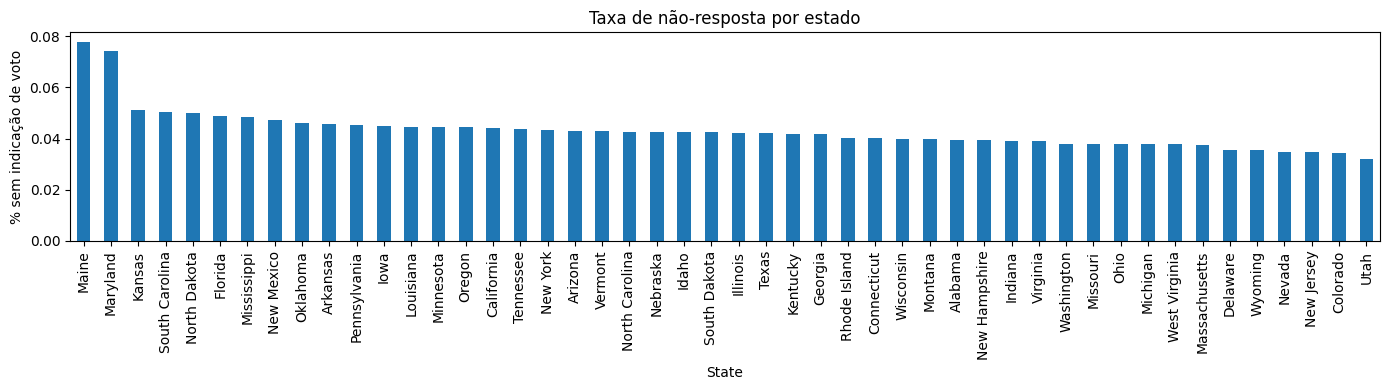

In [26]:
# Taxa de não-resposta agregada por estado (as três listas somadas)
df["Total_vote_not_indicated"] = (
    df[[f"{g}_vote_not_indicated" for g in grupos]].sum(axis=1)
)
df["Taxa_nao_resposta_estado"] = (
    df["Total_vote_not_indicated"] / df["Total_indications"]
)

df.sort_values("Taxa_nao_resposta_estado", ascending=False).plot(
    x="State", y="Taxa_nao_resposta_estado", kind="bar", figsize=(14, 4), legend=False
)
plt.title("Taxa de não-resposta por estado")
plt.ylabel("% sem indicação de voto")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

*Previsão da enquete vs. resultado real:*

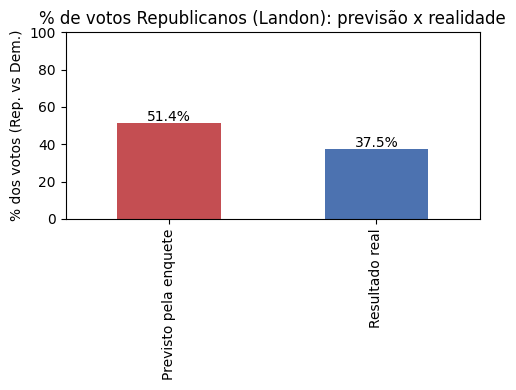

Erro da enquete: 13.9% pontos percentuais
Total de votos em 1936: 45648069.0
Erro da enquete em número de votos: 6328851


In [27]:
# Previsão da enquete: % Republicano entre indicações Rep. x Dem. (soma das 3 listas)
previsto_rep = df[[f"{g}_rep" for g in grupos]].sum().sum()
previsto_dem = df[[f"{g}_dem" for g in grupos]].sum().sum()
previsto_pct_rep = previsto_rep / (previsto_rep + previsto_dem) * 100

# Resultado real da eleição
real_rep = df_votos["Landon_votes"].sum()
real_dem = df_votos["Roosevelt_votes"].sum()
real_pct_rep = real_rep / (real_rep + real_dem) * 100

comparacao = pd.Series({"Previsto pela enquete": previsto_pct_rep, "Resultado real": real_pct_rep})

ax = comparacao.plot(kind="bar", figsize=(5, 4), color=["#C44E52", "#4C72B0"])
plt.title("% de votos Republicanos (Landon): previsão x realidade")
plt.ylabel("% dos votos (Rep. vs Dem.)")
plt.ylim(0, 100)
for i, v in enumerate(comparacao):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.show()

print(f"Erro da enquete: {previsto_pct_rep - real_pct_rep:.1f}% pontos percentuais")
print(f"Total de votos em 1936: {df['Total_votes'].sum()}")
print(f"Erro da enquete em número de votos: {((previsto_pct_rep - real_pct_rep)/100)*df['Total_votes'].sum():.0f}")

## 4. Machine Learning: Desenvolver e aplicar o modelo capaz de prever o resultado das eleições

O objetivo desta etapa é construir um modelo capaz de **corrigir o viés identificado na pesquisa do Literary Digest**, aproximando a previsão de 1936 do resultado real observado em cada estado.

*Modelagem Preditiva Básica*

In [28]:
# Percentual de cada partido no resultado real de 1932 (base de referência, menos sujeita ao viés da pesquisa de 1936)
df["Rep_pct_1932"] = df["Hoover_votes_1932"] / df["Total_votes_1932"] * 100
df["Dem_pct_1932"] = df["Roosevelt_votes_1932"] / df["Total_votes_1932"] * 100

# Variação/Desvio: diferença entre a intenção de voto republicana captada pela pesquisa (1936) e o resultado republicano real de 1932
df["Desvio_poll_1932"] = df["Poll_pct_Landon"] - df["Rep_pct_1932"]

atributos = ["Poll_pct_Landon", "Rep_pct_1932", "Dem_pct_1932", "Desvio_poll_1932", "Taxa_nao_resposta_estado"]
rotulo = "Real_pct_Landon"

X = df[atributos]
y = df[rotulo]

print(f"Dimensão de X: {X.shape}\nDimensão de y: {y.shape}")
X.describe()

Dimensão de X: (48, 5)
Dimensão de y: (48,)


,Poll_pct_Landon,Rep_pct_1932,Dem_pct_1932,Desvio_poll_1932,Taxa_nao_resposta_estado
count,48.000000,48.000000,48.000000,48.000000,48.000000
mean,50.301355,34.981368,62.769027,15.319987,0.043112
std,15.251195,13.368808,14.072514,6.958945,0.008194
min,12.093554,1.894509,41.076069,-2.225267,0.032053
25%,43.095788,30.420096,54.368091,11.424101,0.038699
50%,54.257901,36.586714,58.730436,16.588475,0.042396
75%,59.428835,43.511495,68.699151,19.480397,0.044688
max,74.238026,57.660972,98.026952,26.886252,0.077606


*Divisão dos dados em treino e teste*

In [29]:
# Divisão de treino em 80% e teste em 20%
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print(f"Formato treino: {X_train.shape}\nFormato teste: {X_test.shape}")

Formato treino: (38, 5)
Formato teste: (10, 5)


*Modelo de Regressão Linear*

Para tratar de um problema de aproximação de um porcentual contínuo, e começar pelo mais "simples", esse é o primeiro modelo testado.

In [30]:
pipeline_RL = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", LinearRegression())
])
pipeline_RL.fit(X_train, y_train)
pred_RL_test = pipeline_RL.predict(X_test)

print(f"Coeficientes do modelo (na escala padronizada): {dict(zip(atributos, pipeline_RL.named_steps['reg'].coef_.round(2)))}")

Coeficientes do modelo (na escala padronizada): {'Poll_pct_Landon': np.float64(11.65), 'Rep_pct_1932': np.float64(15.41), 'Dem_pct_1932': np.float64(15.29), 'Desvio_poll_1932': np.float64(-3.97), 'Taxa_nao_resposta_estado': np.float64(1.18)}


*Validação cruzada do modelo linear*

Realização de uma validação cruzada para poder treinar o modelo diversas vezes, sendo dividido em partes iguais e repetindo x vezes, sendo x o quanto ele foi dividido.

In [31]:
cv_scores_RL = cross_val_score(pipeline_RL, X, y, cv=5, scoring="neg_mean_absolute_error")

print(f"MAE por partição (validação cruzada, 5 folds): {(-cv_scores_RL).round(2)}")
print(f"MAE médio: {(-cv_scores_RL).mean():.2f} p.p. (desvio-padrão: {cv_scores_RL.std():.2f})")

MAE por partição (validação cruzada, 5 folds): [2.13 2.36 3.36 3.4  2.55]
MAE médio: 2.76 p.p. (desvio-padrão: 0.52)


*Modelo de Random Forest Regressor (comparação com um modelo não-linear)*

Como comparação, treinamos também um modelo não-linear, capaz de capturar eventuais relações mais complexas entre as características de viés e o resultado real.

In [32]:
pipeline_RF = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", RandomForestRegressor(n_estimators=200, random_state=42))
])

pipeline_RF.fit(X_train, y_train)
pred_RF_test = pipeline_RF.predict(X_test)

pipeline_RF

Pipeline(steps=[('scaler', StandardScaler()),
                ('reg',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

*Validação cruzada do modelo RF*

Realização de uma validação cruzada para poder treinar o modelo diversas vezes, sendo dividido em partes iguais e repetindo x vezes, sendo x o quanto ele foi dividido.

In [33]:
cv_scores_RF = cross_val_score(pipeline_RF, X, y, cv=5, scoring="neg_mean_absolute_error")

print(f"MAE por partição (validação cruzada, 5 folds): {(-cv_scores_RF).round(2)}")
print(f"MAE médio: {(-cv_scores_RF).mean():.2f} p.p. (desvio-padrão: {cv_scores_RF.std():.2f})")

MAE por partição (validação cruzada, 5 folds): [3.06 4.26 3.24 4.13 4.54]
MAE médio: 3.85 p.p. (desvio-padrão: 0.59)


## 5. Resultados: Teste e pontuação do modelo

*Regressão Linear x Random Forest*

In [34]:
metricas = pd.DataFrame({
    "Regressão Linear": {
        "MAE (p.p.)": mean_absolute_error(y_test, pred_RL_test),
        "RMSE (p.p.)": mean_squared_error(y_test, pred_RL_test) ** 0.5,
        "R²": r2_score(y_test, pred_RL_test),
    },
    "Random Forest": {
        "MAE (p.p.)": mean_absolute_error(y_test, pred_RF_test),
        "RMSE (p.p.)": mean_squared_error(y_test, pred_RF_test) ** 0.5,
        "R²": r2_score(y_test, pred_RF_test),
    },
}).round(3)

metricas

,Regressão Linear,Random Forest
MAE (p.p.),3.106,3.477
RMSE (p.p.),3.429,3.861
R²,0.939,0.923


*Erro do modelo corrigido x erro bruto da pesquisa*

Comparar o erro do modelo de correção nos estados de teste com o erro que a revista teria cometido nesses estados.

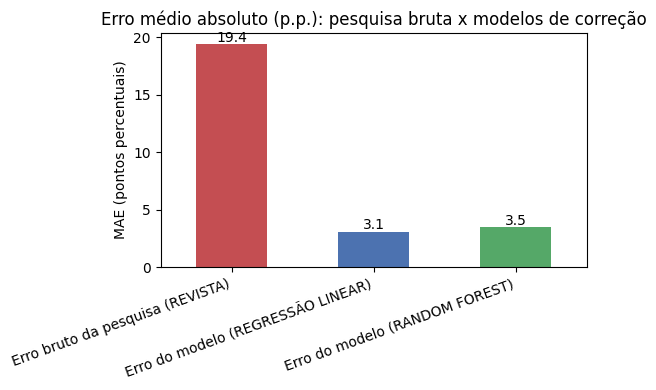

Redução de erro (Regressão Linear): 16.30 p.p.
Redução de erro (Random Forest):    15.93 p.p.


In [35]:
erro_bruto_pesquisa = df.loc[X_test.index, "Erro_Landon_abs"].mean()
erro_modelo_RL = mean_absolute_error(y_test, pred_RL_test)
erro_modelo_RF = mean_absolute_error(y_test, pred_RF_test)

comparacao_erros = pd.Series({
    "Erro bruto da pesquisa (REVISTA)": erro_bruto_pesquisa,
    "Erro do modelo (REGRESSÃO LINEAR)": erro_modelo_RL,
    "Erro do modelo (RANDOM FOREST)": erro_modelo_RF,
})

ax = comparacao_erros.plot(kind="bar", figsize=(6, 4), color=["#C44E52", "#4C72B0", "#55A868"])
plt.title("Erro médio absoluto (p.p.): pesquisa bruta x modelos de correção")
plt.ylabel("MAE (pontos percentuais)")
plt.xticks(rotation=20, ha="right")
for i, v in enumerate(comparacao_erros):
    ax.text(i, v + 0.2, f"{v:.1f}", ha="center")
plt.tight_layout()
plt.show()

print(f"Redução de erro (Regressão Linear): {erro_bruto_pesquisa - erro_modelo_RL:.2f} p.p.")
print(f"Redução de erro (Random Forest):    {erro_bruto_pesquisa - erro_modelo_RF:.2f} p.p.")

*Previsto no modelo X Resultado Real*

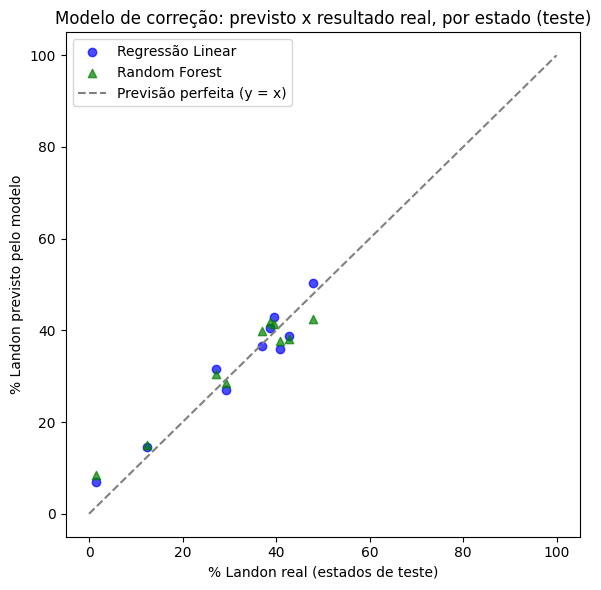

In [36]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred_RL_test, alpha=0.7, label="Regressão Linear", color="blue")
plt.scatter(y_test, pred_RF_test, alpha=0.7, label="Random Forest", color="green", marker="^")

lims = [0, 100]
plt.plot(lims, lims, linestyle="--", color="gray", label="Previsão perfeita (y = x)")

plt.xlabel("% Landon real (estados de teste)")
plt.ylabel("% Landon previsto pelo modelo")
plt.title("Modelo de correção: previsto x resultado real, por estado (teste)")
plt.legend()
plt.tight_layout()
plt.show()

*Precisão na previsão do vencedor por estado*

Avaliamos se o modelo acerta o vencedor de cada estado, usando o "Electoral_winner_id".

Acurácia na previsão do vencedor (Regressão Linear): 90.00%
Acurácia na previsão do vencedor (Random Forest):    100.00%


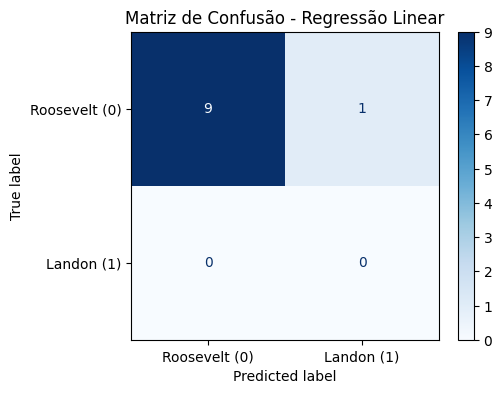

In [37]:
y_vencedor_test = df.loc[X_test.index, "Electoral_winner_id"]

pred_vencedor_RL = (pred_RL_test > 50).astype(int)
pred_vencedor_RF = (pred_RF_test > 50).astype(int)

acc_lr = accuracy_score(y_vencedor_test, pred_vencedor_RL)
acc_rf = accuracy_score(y_vencedor_test, pred_vencedor_RF)

print(f"Acurácia na previsão do vencedor (Regressão Linear): {acc_lr:.2%}")
print(f"Acurácia na previsão do vencedor (Random Forest):    {acc_rf:.2%}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_vencedor_test, pred_vencedor_RL,
    display_labels=["Roosevelt (0)", "Landon (1)"],
    cmap="Blues", ax=ax
)
plt.title("Matriz de Confusão - Regressão Linear")
plt.show()

## 6. Conclusão

Com base nos resultados obtidos, podemos concluir que: pequenos valores errôneos ou simples anomalias podem ser suficientes para mudar completamente o resultado de uma previsão. Dados bem organizados e com enviesamento minimizado produzem respostas superiores a conjuntos de dados massivos, porém mal organizados ou enviesados; o que foi justamente o caso dos registros coletados pela Literary Digest. A cuidadosa limpeza, análise e transformação dos dados são fundamentais para gerar resultados precisos, que quando utilizados para treinamento de máquina, criam ferramentas verdadeiramente poderosas.

